# 07_1_AM_MHCII_AT2_VIM_Categorical_Spatial_Association
## Xiaonan Wang
## 20Sep2026

In [1]:
#%matplotlib nbagg
import numpy as np
import matplotlib.pyplot as plt
import scanpy as sc
import pandas as pd
from os import listdir
from os.path import isfile, join
import re
import anndata
# import scvi

plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42

sc.settings.verbosity = 3  # verbosity: errors (0), warnings (1), info (2), hints (3)

from matplotlib.colors import LinearSegmentedColormap
cmap = LinearSegmentedColormap.from_list(name='gene_cmap', colors=['lightgrey', '#a1a1ce', 'purple', '#301934']) 
sc.settings.set_figure_params(dpi=80, color_map='viridis', vector_friendly=False,  dpi_save=300)

In [2]:
import sys

project_dir = "/dssg/home/acct-svetoslav_chakarov/svetoslav_chakarov/Data/External_Data/Xu_NC2026_human/analysis_v1"

if project_dir not in sys.path:
    sys.path.append(project_dir)

import source

In [3]:
sc.logging.print_header()

Package,Version
numpy,2.4.5
matplotlib,3.10.9
scanpy,1.11.5
pandas,2.3.3
anndata,0.12.14
Component,Info
Python,"3.11.6 | packaged by conda-forge | (main, Oct 3 2023, 10:40:35) [GCC 12.3.0]"
OS,Linux-4.18.0-553.81.1.el8_10.x86_64-x86_64-with-glibc2.28
CPU,"17/64 logical CPU cores, x86_64"
GPU,No GPU found


In [3]:
datadir = "/dssg/home/acct-svetoslav_chakarov/svetoslav_chakarov/Data/External_Data/Xu_NC2026_human/data/Spatial/"
outdir = "/dssg/home/acct-svetoslav_chakarov/svetoslav_chakarov/Data/External_Data/Xu_NC2026_human/analysis_v1/write_all/"

## Step 0 - Read In Files

In [5]:
x_all = sc.read_h5ad(datadir + "all_updated.h5ad")

In [6]:
AT2 = sc.read_h5ad(outdir + "AT2_updated.h5ad")

In [7]:
x_all, report_AT2 = source.merge_obs_to_main(
    main_adata=x_all,
    subset_adata=AT2,
    columns={
        "AT2_VIMhi_score": "AT2_VIMhi_score",
        "AT2_VIMlo_score": "AT2_VIMlo_score",
        "AT2_VIM_score": "AT2_VIM_score",
        "AT2_VIM_group": "AT2_VIM_group",
    },
    overwrite=True,
    strict_subset=True,
    source_name="AM",
)

In [8]:
display(
    x_all.obs.loc[
        x_all.obs["CellType_refined"].isin(
            ["AM", "Alveolar Macrophage"]
        ),
        "MHCII_group",
    ].value_counts(dropna=False)
)

display(
    x_all.obs.loc[
        x_all.obs["CellType_refined"].eq("AT2"),
        "AT2_VIM_group",
    ].value_counts(dropna=False)
)

MHCII_group
MHCIIlo    11660
MHCIIhi     5456
Name: count, dtype: int64

AT2_VIM_group
VIMhi    11766
VIMlo     9729
Name: count, dtype: int64

In [9]:
import os
if hasattr(os, "sched_getaffinity"):
    print(
        "Available CPUs:",
        len(os.sched_getaffinity(0)),
    )
else:
    print(
        "Available CPUs:",
        os.cpu_count(),
    )

Available CPUs: 17


## Step1 - Categorical Common Settings

In [10]:
stage3_categorical_common = {
    # Metadata
    "core_col": "core_id",
    "donor_col": "donor_id",
    "tissue_col": "tissue_annotation",
    "tissue": None,

    # Cell types
    "celltype_col": "CellType_refined",
    "am_labels": ("AM", "Alveolar Macrophage"),
    "at2_labels": ("AT2",),

    # Spatial coordinates
    "x_col": "x_centroid",
    "y_col": "y_centroid",

    # AM categorical state
    "mhcii_group_col": "MHCII_group",
    "mhcii_hi_label": "MHCIIhi",
    "mhcii_lo_label": "MHCIIlo",

    # AT2 categorical state
    "vim_group_col": "AT2_VIM_group",
    "vim_hi_label": "VIMhi",
    "vim_lo_label": "VIMlo",

    # Permutations within each core
    "n_permutations": 999,
}

## Step2 - Four-state Pair Enrichment

log concordance odds ratio
- Positive: MHCIIhi–VIMhi and MHCIIlo–VIMlo

In [11]:
stage3_cat_pairs = run_stage3_multicore(
    analysis_function=(
        calculate_stage3_categorical_pair_enrichment_by_core
    ),
    adata=x_all,
    n_jobs=16,
    random_state=401,
    verbose=10,

    radii=(25, 50, 100),
    min_am_per_group=5,
    min_at2_per_group=5,
    odds_correction=0.5,

    **stage3_categorical_common,
)

[Parallel(n_jobs=16)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done   9 tasks      | elapsed:    2.5s
[Parallel(n_jobs=16)]: Done  18 tasks      | elapsed:    3.1s
[Parallel(n_jobs=16)]: Done  29 tasks      | elapsed:    4.3s
[Parallel(n_jobs=16)]: Done  47 out of  70 | elapsed:    6.0s remaining:    2.9s
[Parallel(n_jobs=16)]: Done  55 out of  70 | elapsed:    6.6s remaining:    1.8s
[Parallel(n_jobs=16)]: Done  63 out of  70 | elapsed:    8.5s remaining:    0.9s
[Parallel(n_jobs=16)]: Done  70 out of  70 | elapsed:   15.3s finished


## Step3 - Categorical kNN Association

mean local VIMhi fraction around MHCIIhi AMs − mean local VIMhi fraction around MHCIIlo AMs

In [12]:
stage3_cat_knn = run_stage3_multicore(
    analysis_function=(
        calculate_stage3_categorical_knn_by_core
    ),
    adata=x_all,
    n_jobs=16,
    random_state=402,
    verbose=10,

    k_values=(5, 15, 30),
    neighbor_pool="all",

    min_at2_neighbors=3,
    min_am_per_group=5,

    balance_am_groups=True,
    n_balance_repeats=100,

    **stage3_categorical_common,
)

[Parallel(n_jobs=16)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Batch computation too fast (0.08476424217224121s.) Setting batch_size=2.
[Parallel(n_jobs=16)]: Done   9 tasks      | elapsed:    1.5s
[Parallel(n_jobs=16)]: Done  18 tasks      | elapsed:    2.7s
[Parallel(n_jobs=16)]: Batch computation too slow (2.655117988586426s.) Setting batch_size=1.
[Parallel(n_jobs=16)]: Done  31 out of  70 | elapsed:    3.7s remaining:    4.6s
[Parallel(n_jobs=16)]: Done  39 out of  70 | elapsed:    4.0s remaining:    3.2s
[Parallel(n_jobs=16)]: Done  47 out of  70 | elapsed:    5.6s remaining:    2.7s
[Parallel(n_jobs=16)]: Done  55 out of  70 | elapsed:    6.4s remaining:    1.7s
[Parallel(n_jobs=16)]: Done  63 out of  70 | elapsed:    7.3s remaining:    0.8s
[Parallel(n_jobs=16)]: Done  70 out of  70 | elapsed:    9.8s finished


## Step4 - Categorical Radius Association

same interpretation as the kNN analysis, evaluated within fixed radii

In [13]:
stage3_cat_radius = run_stage3_multicore(
    analysis_function=(
        calculate_stage3_categorical_radius_by_core
    ),
    adata=x_all,
    n_jobs=16,
    random_state=403,
    verbose=10,

    radii=(25, 50, 100),

    min_at2_neighbors=3,
    min_am_per_group=5,

    balance_am_groups=True,
    n_balance_repeats=100,

    **stage3_categorical_common,
)

[Parallel(n_jobs=16)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Batch computation too fast (0.0788729190826416s.) Setting batch_size=2.
[Parallel(n_jobs=16)]: Done   9 tasks      | elapsed:    3.5s
[Parallel(n_jobs=16)]: Done  18 tasks      | elapsed:    4.5s
[Parallel(n_jobs=16)]: Done  31 out of  70 | elapsed:    6.5s remaining:    8.1s
[Parallel(n_jobs=16)]: Done  47 out of  70 | elapsed:    9.0s remaining:    4.4s
[Parallel(n_jobs=16)]: Done  55 out of  70 | elapsed:   10.9s remaining:    3.0s
[Parallel(n_jobs=16)]: Done  70 out of  70 | elapsed:   19.6s finished


## Step5 - Nearest-AT2 Categorical Association

log odds ratio
- Positive: MHCIIhi AMs are more likely to have VIMhi as their nearest AT2
- Negative: MHCIIhi AMs are more likely to have VIMlo as their nearest AT2

In [14]:
stage3_cat_nearest = run_stage3_multicore(
    analysis_function=(
        calculate_stage3_categorical_nearest_at2_by_core
    ),
    adata=x_all,
    n_jobs=16,
    random_state=404,
    verbose=10,

    max_distance=100,
    min_am_per_group=5,
    odds_correction=0.5,

    **stage3_categorical_common,
)

[Parallel(n_jobs=16)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Batch computation too fast (0.11668515205383301s.) Setting batch_size=2.
[Parallel(n_jobs=16)]: Done   9 tasks      | elapsed:    0.2s
[Parallel(n_jobs=16)]: Done  18 tasks      | elapsed:    0.3s
[Parallel(n_jobs=16)]: Done  31 out of  70 | elapsed:    0.4s remaining:    0.6s
[Parallel(n_jobs=16)]: Done  47 out of  70 | elapsed:    0.6s remaining:    0.3s
[Parallel(n_jobs=16)]: Done  55 out of  70 | elapsed:    0.7s remaining:    0.2s
[Parallel(n_jobs=16)]: Done  63 out of  70 | elapsed:    0.9s remaining:    0.1s
[Parallel(n_jobs=16)]: Done  70 out of  70 | elapsed:    1.5s finished


## Step6 - Combine Results

In [15]:
stage3_categorical_results = pd.concat(
    [
        stage3_cat_pairs,
        stage3_cat_knn,
        stage3_cat_radius,
        stage3_cat_nearest,
    ],
    ignore_index=True,
    sort=False,
)

stage3_categorical_results = (
    stage3_categorical_results
    .sort_values(
        [
            "method",
            "scale",
            "tissue_annotation",
            "donor_id",
            "core_id",
        ]
    )
    .reset_index(drop=True)
)

display(stage3_categorical_results.head())

display(
    stage3_categorical_results
    .groupby(["method", "scale"])
    .size()
)

,core_id,donor_id,tissue_annotation,n_am_total,n_am_categorized,n_am_excluded,am_retained_fraction,n_at2_total,n_at2_categorized,n_at2_excluded,...,z_hi_hi,fdr_bh,n_mhcii_hi_analyzed,n_mhcii_lo_analyzed,n_am_analyzed,coverage_fraction,median_at2_neighbors,balance_am_groups,n_balance_repeats,median_nearest_distance
0,D1.c1,D1,A,164,164,0,1.0,680,680,0,...,NaN,0.216,26.0,14.0,40.0,0.243902,4.0,True,100.0,NaN
1,D1.c2,D1,A,203,203,0,1.0,961,961,0,...,NaN,0.222,25.0,22.0,47.0,0.231527,4.0,True,100.0,NaN
2,D10.c1,D10,A,1476,1476,0,1.0,510,510,0,...,NaN,0.606,42.0,53.0,95.0,0.064363,3.0,True,100.0,NaN
3,D10.c2,D10,A,815,815,0,1.0,807,807,0,...,NaN,0.606,59.0,62.0,121.0,0.148466,4.0,True,100.0,NaN
4,D14.c1,D14,A,1230,1230,0,1.0,333,333,0,...,NaN,0.138,8.0,64.0,72.0,0.058537,3.0,True,100.0,NaN


method                       scale
categorical_knn              15.0     28
                             30.0     44
categorical_nearest_at2      100.0    61
categorical_pair_enrichment  25.0     64
                             50.0     64
                             100.0    64
categorical_radius           25.0     12
                             50.0     36
                             100.0    54
dtype: int64

## Step7 - Check Ambiguous-state Exclusions

In [16]:
categorical_qc_columns = [
    "core_id",
    "donor_id",
    "tissue_annotation",

    "n_am_total",
    "n_am_categorized",
    "n_am_excluded",
    "am_retained_fraction",

    "n_at2_total",
    "n_at2_categorized",
    "n_at2_excluded",
    "at2_retained_fraction",
]

categorical_qc = (
    stage3_categorical_results[
        categorical_qc_columns
    ]
    .drop_duplicates()
    .sort_values(
        ["tissue_annotation", "donor_id", "core_id"]
    )
)

display(categorical_qc.head())

,core_id,donor_id,tissue_annotation,n_am_total,n_am_categorized,n_am_excluded,am_retained_fraction,n_at2_total,n_at2_categorized,n_at2_excluded,at2_retained_fraction
0,D1.c1,D1,A,164,164,0,1.0,680,680,0,1.0
1,D1.c2,D1,A,203,203,0,1.0,961,961,0,1.0
2,D10.c1,D10,A,1476,1476,0,1.0,510,510,0,1.0
3,D10.c2,D10,A,815,815,0,1.0,807,807,0,1.0
32,D11.c2,D11,A,188,188,0,1.0,747,747,0,1.0


In [17]:
display(
    categorical_qc.groupby(
        "tissue_annotation",
        observed=True,
    )[
        [
            "am_retained_fraction",
            "at2_retained_fraction",
        ]
    ].agg(["median", "min", "max"])
)

am_retained_fraction           at2_retained_fraction       \
                                median  min  max                median  min   
tissue_annotation                                                             
A                                  1.0  1.0  1.0                   1.0  1.0   
B                                  1.0  1.0  1.0                   1.0  1.0   
None                               1.0  1.0  1.0                   1.0  1.0   
V                                  1.0  1.0  1.0                   1.0  1.0   

                        
                   max  
tissue_annotation       
A                  1.0  
B                  1.0  
None               1.0  
V                  1.0

## Step8 - Donor and Tisue-level Inference

In [18]:
(
    stage3_categorical_donor_summary,
    stage3_categorical_tissue_tests,
) = summarize_stage3_by_donor_and_tissue(
    stage3_categorical_results,
    donor_col="donor_id",
    tissue_col="tissue_annotation",
    core_col="core_id",
    min_donors=3,
)

display(stage3_categorical_donor_summary.head())
display(stage3_categorical_tissue_tests.head())

,method,scale,scale_type,effect_name,tissue_annotation,donor_id,donor_effect,donor_effect_transformed,n_cores,mean_core_effect,median_core_effect,n_am_analyzed
0,categorical_knn,15.0,k_neighbors,difference_in_local_vimhi_fraction,A,D1,0.116044,0.116044,2,0.116044,0.116044,87.0
1,categorical_knn,15.0,k_neighbors,difference_in_local_vimhi_fraction,A,D10,-0.041928,-0.041928,2,-0.041928,-0.041928,216.0
2,categorical_knn,15.0,k_neighbors,difference_in_local_vimhi_fraction,A,D14,-0.133333,-0.133333,1,-0.133333,-0.133333,72.0
3,categorical_knn,15.0,k_neighbors,difference_in_local_vimhi_fraction,A,D15,0.048611,0.048611,1,0.048611,0.048611,35.0
4,categorical_knn,15.0,k_neighbors,difference_in_local_vimhi_fraction,A,D16,-0.054167,-0.054167,1,-0.054167,-0.054167,22.0


,method,scale,scale_type,effect_name,tissue_annotation,n_donors,mean_effect,median_effect,ci_low,ci_high,p_value,direction,fdr_bh
0,categorical_knn,15.0,k_neighbors,difference_in_local_vimhi_fraction,A,10,-0.029311,-0.038439,-0.089737,0.031114,0.275391,negative,0.809569
1,categorical_knn,15.0,k_neighbors,difference_in_local_vimhi_fraction,V,8,-0.063641,-0.051075,-0.137752,0.010470,0.078125,negative,0.390625
2,categorical_knn,30.0,k_neighbors,difference_in_local_vimhi_fraction,A,15,-0.008325,0.001126,-0.044298,0.027648,0.719727,negative,0.856817
3,categorical_knn,30.0,k_neighbors,difference_in_local_vimhi_fraction,B,4,-0.047699,-0.042799,-0.200746,0.105348,0.625000,negative,0.809569
4,categorical_knn,30.0,k_neighbors,difference_in_local_vimhi_fraction,V,10,-0.041392,-0.008641,-0.110322,0.027538,0.431641,negative,0.809569


## Step9 - Save All Results

In [19]:
stage3_categorical_results_dict = {
    "pair_enrichment": stage3_cat_pairs,
    "knn": stage3_cat_knn,
    "radius": stage3_cat_radius,
    "nearest_at2": stage3_cat_nearest,

    "combined": stage3_categorical_results,
    "donor_summary": stage3_categorical_donor_summary,
    "tissue_tests": stage3_categorical_tissue_tests,
    "categorical_qc": categorical_qc,

    "settings": stage3_categorical_common,
}

pd.to_pickle(
    stage3_categorical_results_dict,
    "Stage3_categorical_all_results.pkl.gz",
    compression="gzip",
)

In [20]:
stage3_categorical_donor_summary['method'].unique()

array(['categorical_knn', 'categorical_nearest_at2',
       'categorical_pair_enrichment', 'categorical_radius'], dtype=object)

In [30]:
stage3_categorical_donor_summary.loc[(stage3_categorical_donor_summary['method'] == 'categorical_radius') & 
    (stage3_categorical_donor_summary['scale'] == 50.0),:]

,method,scale,scale_type,effect_name,tissue_annotation,donor_id,donor_effect,donor_effect_transformed,n_cores,mean_core_effect,median_core_effect,n_am_analyzed
224,categorical_radius,50.0,radius_um,difference_in_local_vimhi_fraction,A,D1,0.011676,0.011676,2,0.011676,0.011676,230.0
225,categorical_radius,50.0,radius_um,difference_in_local_vimhi_fraction,A,D10,-0.001440,-0.001440,2,-0.001440,-0.001440,562.0
226,categorical_radius,50.0,radius_um,difference_in_local_vimhi_fraction,A,D11,-0.058978,-0.058978,1,-0.058978,-0.058978,81.0
227,categorical_radius,50.0,radius_um,difference_in_local_vimhi_fraction,A,D12,-0.076680,-0.076680,1,-0.076680,-0.076680,42.0
228,categorical_radius,50.0,radius_um,difference_in_local_vimhi_fraction,A,D14,-0.030725,-0.030725,2,-0.030725,-0.030725,255.0
229,categorical_radius,50.0,radius_um,difference_in_local_vimhi_fraction,A,D15,-0.039583,-0.039583,1,-0.039583,-0.039583,50.0
230,categorical_radius,50.0,radius_um,difference_in_local_vimhi_fraction,A,D16,-0.080119,-0.080119,1,-0.080119,-0.080119,25.0
231,categorical_radius,50.0,radius_um,difference_in_local_vimhi_fraction,A,D2,-0.040610,-0.040610,2,-0.040610,-0.040610,245.0
232,categorical_radius,50.0,radius_um,difference_in_local_vimhi_fraction,A,D21,-0.081556,-0.081556,3,-0.081556,-0.061314,156.0
233,categorical_radius,50.0,radius_um,difference_in_local_vimhi_fraction,A,D5,-0.034828,-0.034828,3,-0.034828,-0.049068,112.0


## Step10 - Plotting

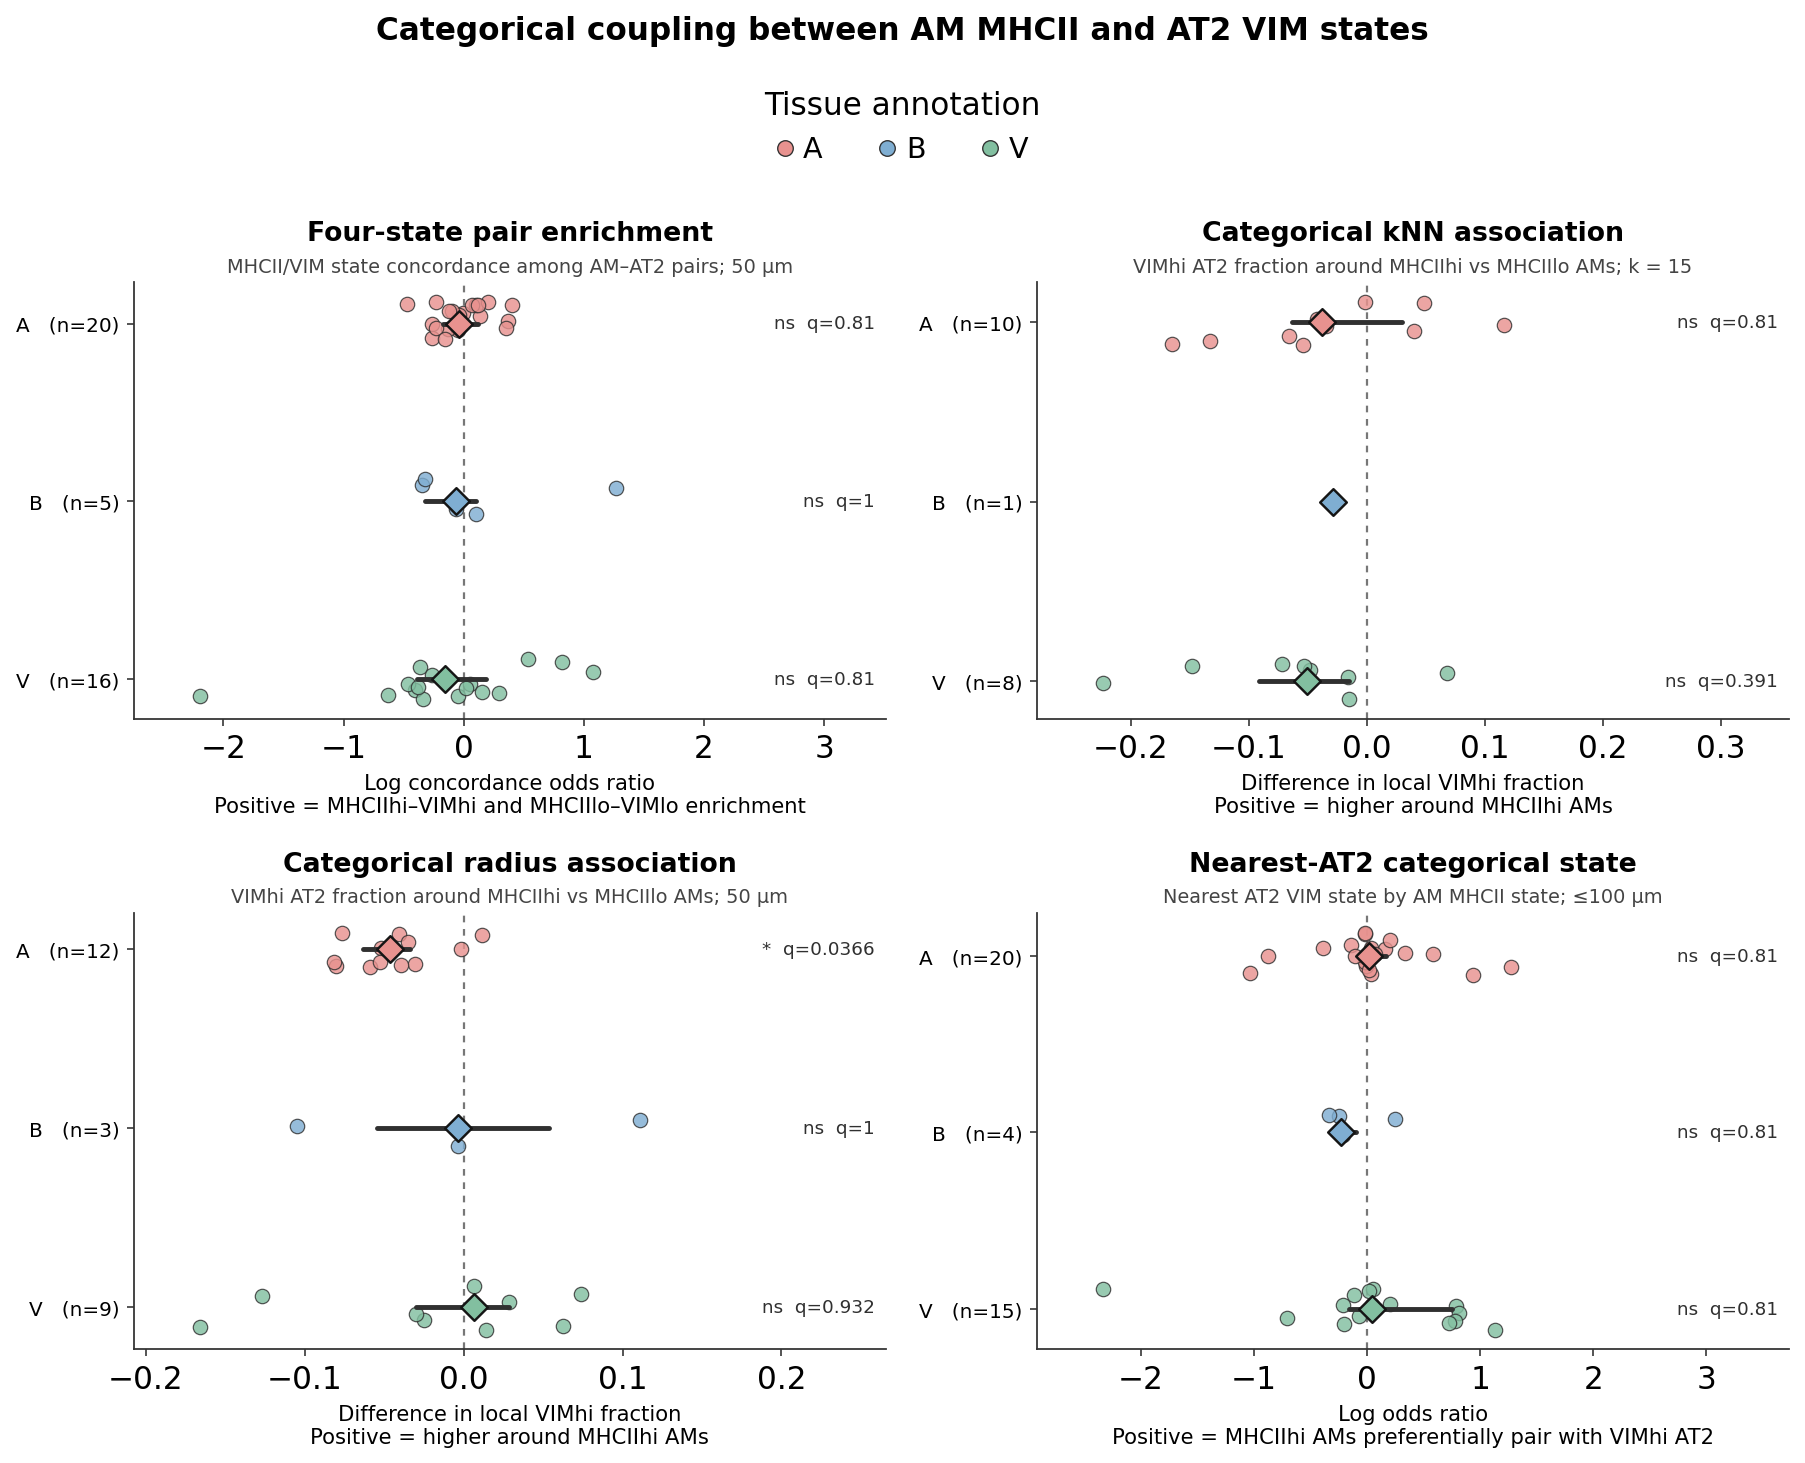

In [22]:
fig, axes, stage3_categorical_primary_data = (
    plot_stage3_categorical_primary(
        donor_summary=stage3_categorical_donor_summary,
        tissue_tests=stage3_categorical_tissue_tests,

        tissue_order=("A", "B", "V"),

        tissue_colors={
            "A": "#E8928F",
            "B": "#7FAED2",
            "V": "#82BFA0",
            "None": "#B8B8B8",
        },

        primary_scales={
            "categorical_pair_enrichment": 50,
            "categorical_knn": 15,
            "categorical_radius": 50,
            "categorical_nearest_at2": 100,
        },

        show_donor_labels=False,
        annotate_fdr=True,

        save="Stage3_categorical_primary_results.pdf",
        dpi=300,
    )
)

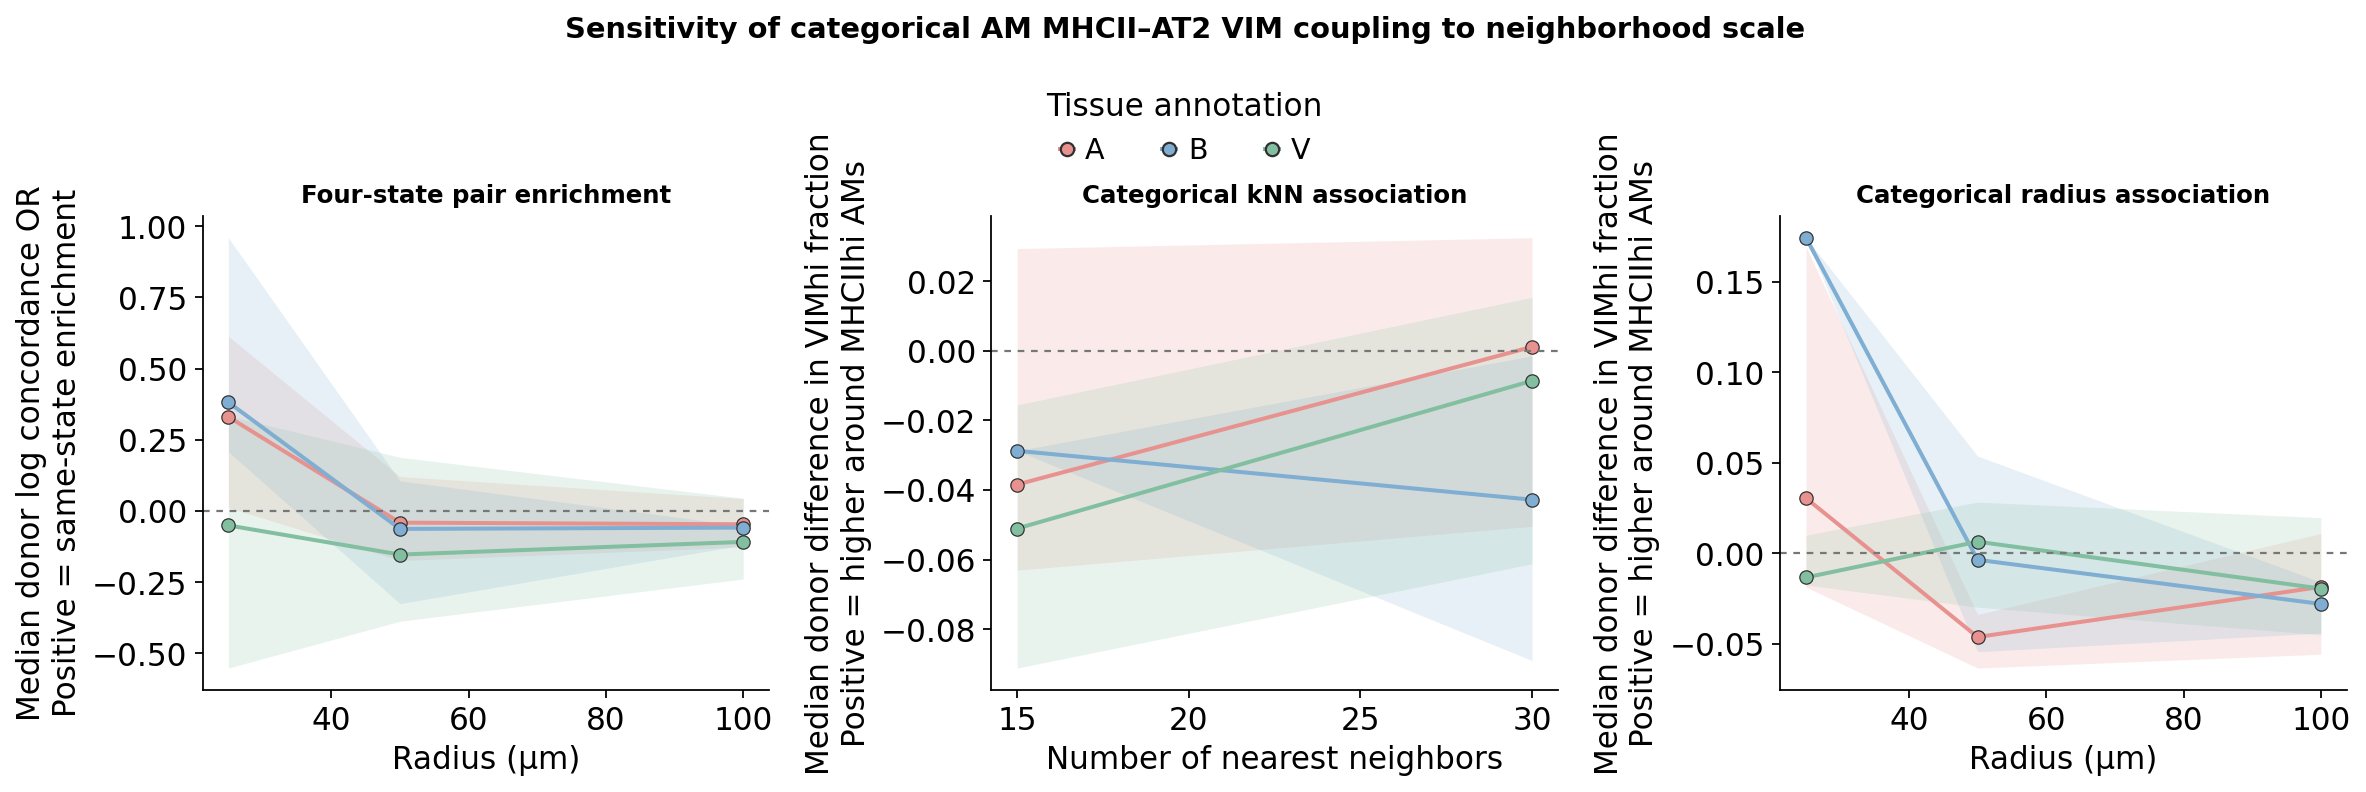

In [23]:
fig, axes, stage3_categorical_scale_summary = (
    plot_stage3_categorical_scale_sensitivity(
        donor_summary=stage3_categorical_donor_summary,

        tissue_order=("A", "B", "V"),

        tissue_colors={
            "A": "#E8928F",
            "B": "#7FAED2",
            "V": "#82BFA0",
            "None": "#B8B8B8",
        },

        save="Stage3_categorical_scale_sensitivity.pdf",
        dpi=300,
    )
)

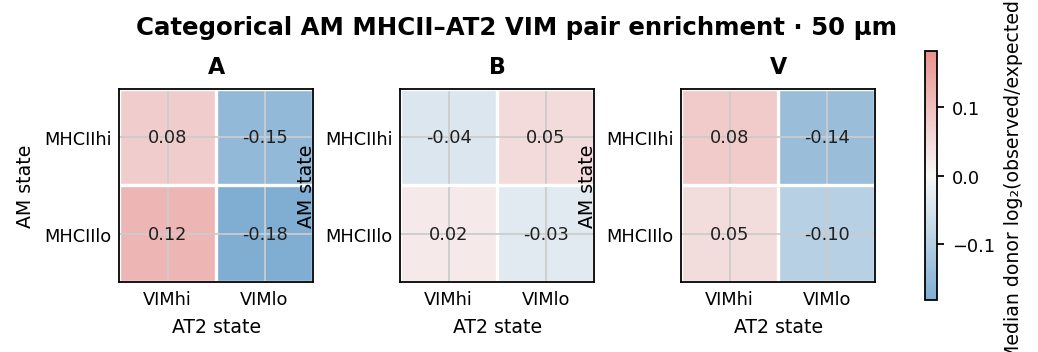

In [24]:
fig, axes, stage3_pair_heatmap_summary = (
    plot_stage3_categorical_pair_heatmap(
        pair_results=stage3_cat_pairs,

        scale=50,
        tissue_order=("A", "B", "V"),

        value="log2_oe",

        save="Stage3_categorical_pair_enrichment_50um.pdf",
        dpi=300,
    )
)

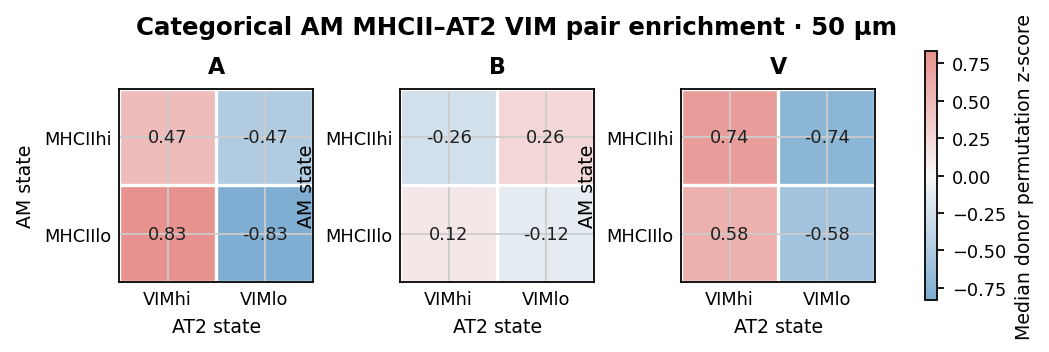

In [25]:
fig, axes, stage3_pair_z_summary = (
    plot_stage3_categorical_pair_heatmap(
        pair_results=stage3_cat_pairs,
        scale=50,
        tissue_order=("A", "B", "V"),
        value="z",
        save="Stage3_categorical_pair_zscore_50um.pdf",
        dpi=300,
    )
)